In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_excel(r"C:\Users\BHAVANI SARAGANDLA\Downloads\salary_prediction_dataset.xlsx")

In [3]:
df.head()

,EmployeeID,Age,YearsExperience,Education,JobRole,City,Salary
0,EMP1000,50,14,Master's,Sales Executive,Chennai,109600
1,EMP1001,32,10,Master's,Marketing Manager,Mumbai,118500
2,EMP1002,43,20,PhD,Marketing Manager,Delhi,160600
3,EMP1003,42,0,Bachelor's,Sales Executive,Pune,51900
4,EMP1004,46,16,Bachelor's,Software Engineer,Pune,124500


In [4]:
df.describe()

,Age,YearsExperience,Salary
count,200.000000,200.000000,200.000000
mean,38.285000,10.595000,101692.000000
std,9.530368,7.295691,28107.657999
min,22.000000,0.000000,34500.000000
25%,30.000000,4.000000,79850.000000
50%,39.000000,9.000000,101800.000000
75%,47.000000,16.000000,120000.000000
max,54.000000,29.000000,186800.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   EmployeeID       200 non-null    object
 1   Age              200 non-null    int64 
 2   YearsExperience  200 non-null    int64 
 3   Education        200 non-null    object
 4   JobRole          200 non-null    object
 5   City             200 non-null    object
 6   Salary           200 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 11.1+ KB


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

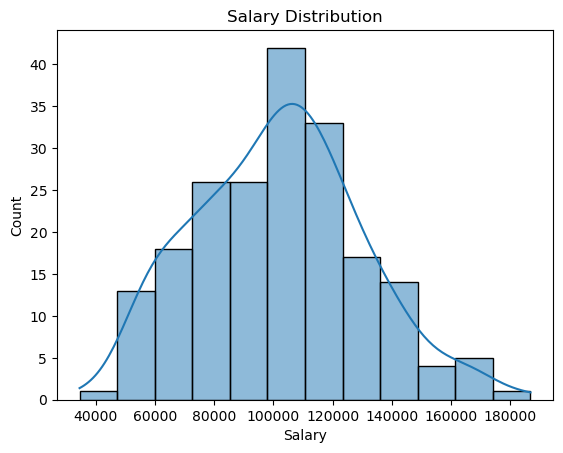

In [7]:
sns.histplot(df["Salary"],kde =True)
plt.title("Salary Distribution")
plt.show()

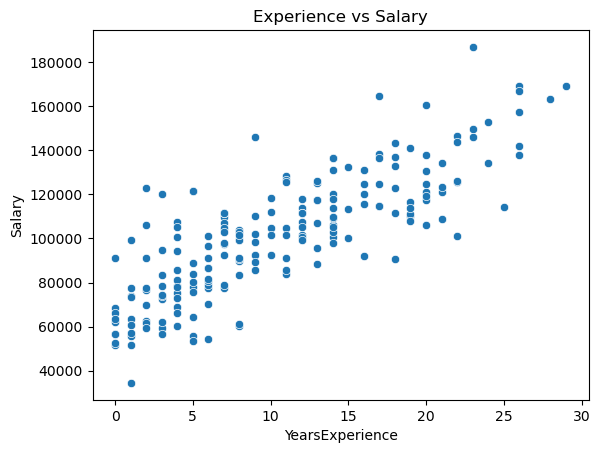

In [8]:

sns.scatterplot(x="YearsExperience",y="Salary",data=df)
plt.title("Experience vs Salary")
plt.show()

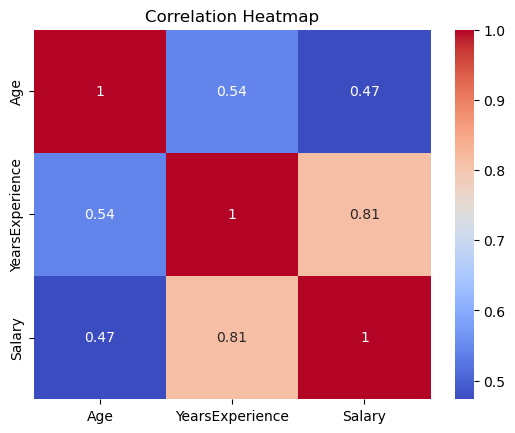

In [9]:
corr = df.select_dtypes(include ="number").corr()
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder ,StandardScaler

In [11]:
df.columns

Index(['EmployeeID', 'Age', 'YearsExperience', 'Education', 'JobRole', 'City',
       'Salary'],
      dtype='object')

In [16]:
X =df.drop(["Salary","EmployeeID"],axis = 1)
y= df["Salary"]

In [17]:
X.head()

,Age,YearsExperience,Education,JobRole,City
0,50,14,Master's,Sales Executive,Chennai
1,32,10,Master's,Marketing Manager,Mumbai
2,43,20,PhD,Marketing Manager,Delhi
3,42,0,Bachelor's,Sales Executive,Pune
4,46,16,Bachelor's,Software Engineer,Pune


In [18]:
y.head()

0    109600
1    118500
2    160600
3     51900
4    124500
Name: Salary, dtype: int64

In [20]:
categorical_columns = X.select_dtypes(include = "object").columns
numerical_columns =X.select_dtypes(exclude ="object").columns

In [42]:
from sklearn.compose import ColumnTransformer
num_transformations =Pipeline(steps = [("imputer",SimpleImputer(strategy ="median")),("scaling",StandardScaler())])
cat_transformations =Pipeline(steps =[("imputer",SimpleImputer(strategy = "most_frequent")),("onehot",OneHotEncoder(handle_unknown="ignore"))])
preprocessor=ColumnTransformer(transformers=[("num",num_transformations,numerical_columns),("cat",cat_transformations,categorical_columns)],remainder ="drop")
X_processed = preprocessor.fit_transform(X)

In [43]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train_processed = preprocessor.fit_transform(X_train)
x_test_processed =preprocessor.fit(X_test)

In [47]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [45]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        random_state=42
    )
}

In [48]:
results = []

for name, model in models.items():

    # Create pipeline
    model_pipeline = Pipeline(steps=[
        ("preprocessor", processor),
        ("model", model)
    ])

    # Train
    model_pipeline.fit(X_train, y_train)

    # Predict
    y_pred = model_pipeline.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
1,Ridge,3460.779307,4333.973499,0.977600
2,Lasso,3529.699625,4338.661822,0.977551
0,Linear Regression,3529.709171,4338.676197,0.977551
5,Gradient Boosting,5776.768067,6897.034714,0.943271
4,Random Forest,7882.795833,9429.436394,0.893965
3,Decision Tree,10417.500000,12751.695966,0.806084


In [49]:
best_model_name = results_df.loc[
    results_df["R2 Score"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Ridge


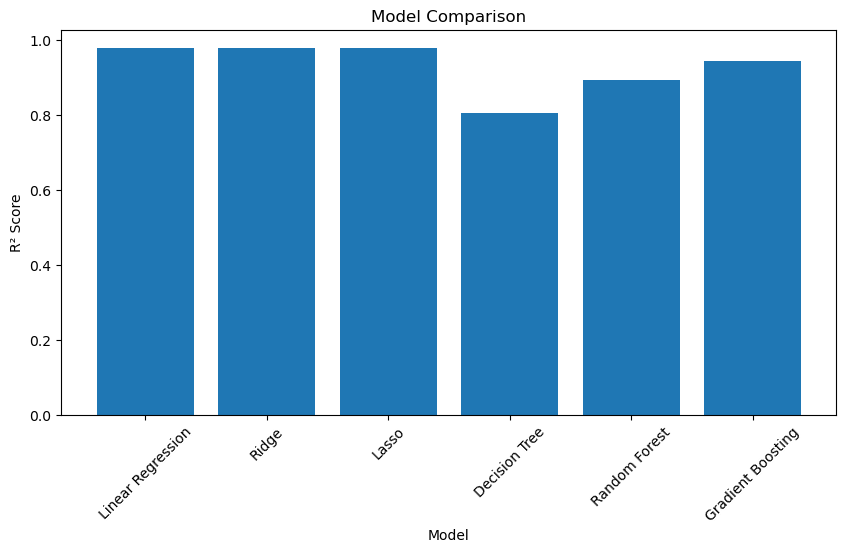

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    results_df["Model"],
    results_df["R2 Score"]
)

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Model Comparison")

plt.xticks(rotation=45)
plt.show()

In [51]:
best_model = models[best_model_name]

final_pipeline = Pipeline(steps=[
    ("preprocessor", processor),
    ("model", best_model)
])

final_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [52]:
import joblib

joblib.dump(final_pipeline, "salary_prediction_model.pkl")

['salary_prediction_model.pkl']